In [1]:
import torch
from torch import nn
import torchvision
import matplotlib.pyplot as plt

In [2]:
mnist_train = torchvision.datasets.FashionMNIST('.', train=True, download=True)
mnist_valid = torchvision.datasets.FashionMNIST('.', train=False, download=True)

In [3]:
x_train = mnist_train.data.reshape(-1, 1, 28, 28) / 255     #.data - 이미지 픽셀 데이터
y_train = mnist_train.targets  #.targets - 라벨 (정답 숫자 0~9)

x_valid = mnist_valid.data.reshape(-1, 1, 28, 28) / 255
y_valid = mnist_valid.targets


# x(이미지)는 reshape 왜 필요?
# CNN 입력은 [배치, 채널, 높이, 너비] 형태를 원함
#           [ -1 ,   1,   28,   28]
# 60000 자동계산(전체 이미지 수),   채널 수 (흑백=1, 컬러=3)
# / 255 -> 픽셀값은 원래 0~255 정수 인데,  0.0~1.0 사이로 정규화

# y(라벨)은 reshape 불필요
# shape = [60000] -> 숫자 하나씩, 이미 완성된 형태
# [5, 0, 4, 1, 9 ...] 그냔ㅇ 정답 숫자 나열

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

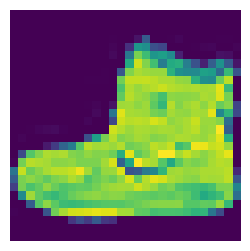

In [4]:
sample = x_train[0][0]
plt.figure(figsize=(3,3))
plt.imshow(sample)
plt.axis('off')


In [5]:
dataset_train = list(zip(x_train, y_train))
dataset_valid = list(zip(x_valid, y_valid))

# x_train(이미지) + y_train(라벨)을 쌍으로 묶음
# [(이미지0, 라벨0), (이미지1, 라벨1), ...]

loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 32)
loader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size = 32)
# 데이터를 32개씩 묶어서 꺼내주는 객체   60000 / 32 = 1875

for x, y in loader_train:
    break

x.shape, y.shape, x.dtype, y.dtype, x.min(), x.max()

(torch.Size([32, 1, 28, 28]),
 torch.Size([32]),
 torch.float32,
 torch.int64,
 tensor(0.),
 tensor(1.))

In [6]:
# 가져올 때

# 1. 이미 학습이 다 된 것을 가져오기
# 2. 학습 도구(model) 가져와서 학습 데이터 내가 준비하기
#    - 학습 루틴까지 가져온다.
#    - 학습툴(tool)이 요구하는 데이터의 포맷을 맞춰줘야 한다.
#    - 짜집기를 잘해야 한다.
#      -> shape, 폴더 구조 등등

In [7]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),        # [32, 32, 28, 28]
    nn.MaxPool2d(2),                                   # [32, 32, 14, 14]
    nn.Conv2d(32, 64, kernel_size=3, padding=1),       # [32, 64, 14, 14]
    nn.MaxPool2d(2),                                   # [32, 64,  7,  7]
    nn.Conv2d(64, 64, kernel_size=3, padding=1),       # [32, 64,  7,  7]
    nn.Flatten(),                                      # [32, 3136] 64x7x7=3136
    nn.Linear(64 * 7 * 7, 10)                          # [32, 10]  3136->10  최종 분류 (숫자 0~9)
)

model(x).shape

# 입력 x : [N, 1, 28, 28]

# torch

torch.Size([32, 10])

In [10]:
model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 16, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),

    nn.Flatten(),

    nn.Linear(64 * 7 * 7, 10)
)

opt = torch.optim.Adam(model.parameters())
loss_fn = torch.nn.CrossEntropyLoss()

logits = model(x)
loss_fn(logits, y)


tensor(2.3000, grad_fn=<NllLossBackward0>)

In [8]:
from torchinfo import summary
summary(model, imput_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Conv2d: 1-1                            320
├─MaxPool2d: 1-2                         --
├─Conv2d: 1-3                            18,496
├─MaxPool2d: 1-4                         --
├─Conv2d: 1-5                            36,928
├─Flatten: 1-6                           --
├─Linear: 1-7                            31,370
Total params: 87,114
Trainable params: 87,114
Non-trainable params: 0

In [ ]:
# 코드 -> 그림, 그림 -> 코드
# 중간 tensor들의 shape
# 파라미터의 개수를 추정할 수 있는가?

In [ ]:
# ---------------------------

# 학습 루프


for epoch in range(10):
    total_loss = 0
    total_acc = 0
    for step, (x, y) in enumerate(loader_train):
        logit = model(x)
        loss = loss_fn(logit, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        total_loss += loss.item()
        
        pred = logit.argmax(axis=1)                       # 가장 높은 점수의 인덱스 -> 예측 숫자
        total_acc += (pred == y).float().mean().item()    # 정답이랑 비교
        
        print('\r epoch=%d,    step=%d    loss=%.4f    acc=%.4f' %
              (epoch, step, total_loss/(step+1), total_acc/(step+1)), end='')

 epoch=9,    step=1874    loss=0.1037    acc=0.9612

In [15]:
for epoch in range(10):
    total_loss = 0
    total_acc = 0
    for step, (x, y) in enumerate(loader_valid):
        with torch.no_grad():
            logit = model(x)
        loss = loss_fn(logit, y)

        #metrics - acc
        total_loss += loss.item()
        pred = logit.argmax(axis=1)
        acc = (pred == y).float().mean()
        total_acc += acc.item()

        print('\r %s step=%d  loss=%.4f  acc=%.4f' %
         (' ' * 20, step, total_loss / (step+1), total_acc / (step + 1)), end='')

                      step=312  loss=0.3786  acc=0.9075

In [17]:
# 검증...

with torch.no_grad():
    logit = model(x_valid)
pred = logit.argmax(axis=1)
acc = (pred == y_valid).float().mean()
acc

tensor(0.9075)

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_valid, pred)
cm

array([[931,   2,   9,  13,   1,   1,  36,   0,   7,   0],
       [  2, 983,   2,  10,   1,   0,   1,   0,   1,   0],
       [ 27,   0, 818,   9,  74,   0,  70,   0,   2,   0],
       [ 30,   2,   8, 911,  32,   0,  16,   0,   1,   0],
       [  3,   1,  29,  24, 880,   0,  63,   0,   0,   0],
       [  0,   0,   0,   0,   0, 972,   0,  22,   2,   4],
       [180,   0,  43,  27,  88,   0, 655,   0,   7,   0],
       [  0,   0,   0,   0,   0,   2,   0, 979,   0,  19],
       [  7,   0,   1,   2,   1,   1,   2,   0, 986,   0],
       [  0,   0,   0,   0,   0,   4,   1,  34,   1, 960]])

<Axes: >

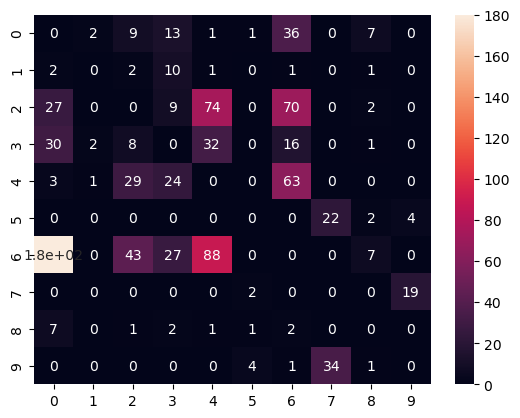

In [29]:
import seaborn as sns
import numpy as np

dcm = cm.copy()
np.fill_diagonal(dcm, 0)
sns.heatmap(dcm, annot=True)
